In [1]:
import pandas as pd

df = pd.read_csv('/content/mushrooms.csv')
display(df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [2]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values[missing_values > 0])

Missing values in each column:


,0


In [3]:
print("Data types of each column:")
display(df.dtypes)

Data types of each column:


,0
class,object
cap-shape,object
cap-surface,object
cap-color,object
bruises,object
odor,object
gill-attachment,object
gill-spacing,object
gill-size,object
gill-color,object


### Data Preprocessing for Decision Tree

Since all features are categorical, we need to convert them into numerical format using one-hot encoding. First, we'll separate the target variable ('class') from the features.

In [4]:
# Separate target variable (y) and features (X)
y = df['class']
X = df.drop('class', axis=1)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (8124, 22)
Shape of target (y): (8124,)


Now, we will apply one-hot encoding to the feature DataFrame `X`.

In [5]:
# Apply one-hot encoding to the features
X_encoded = pd.get_dummies(X)

print("Shape of one-hot encoded features (X_encoded):")
display(X_encoded.shape)
display(X_encoded.head())

Shape of one-hot encoded features (X_encoded):


(8124, 117)

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


### Training a Decision Tree Classifier

Now, we'll split the data into training and testing sets, train a Decision Tree Classifier, and evaluate its performance.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5686, 117)
X_test shape: (2438, 117)
y_train shape: (5686,)
y_test shape: (2438,)


Now, let's train the Decision Tree Classifier.

In [7]:
# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### Model Evaluation

Let's evaluate the performance of our trained Decision Tree Classifier on the test set.

In [9]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1257
           p       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



### Visualizing the Decision Tree

Let's visualize the trained Decision Tree to understand its structure. Due to the potential complexity of the tree, we might need to save it to a file and view it externally or limit its depth for better inline visualization.

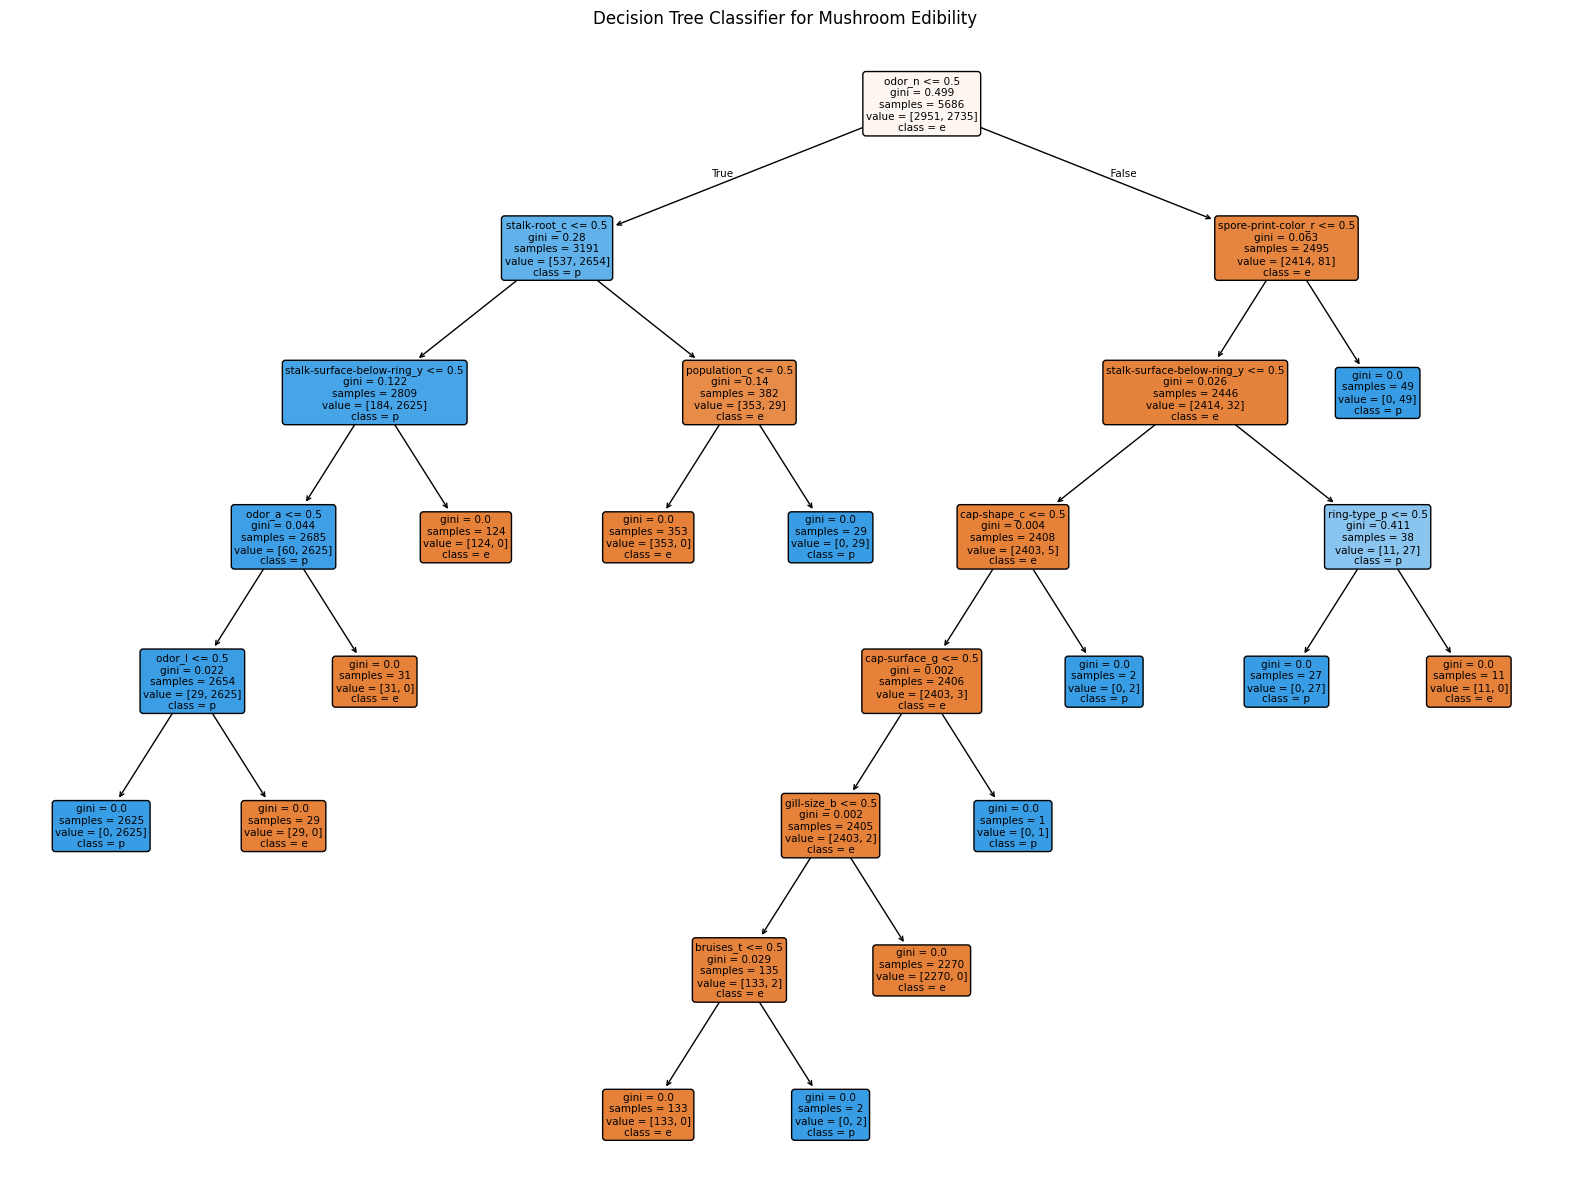

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set a maximum depth for visualization if the tree is too large, or remove for full tree
# max_depth = 5 # Uncomment and adjust if needed

plt.figure(figsize=(20,15))
plot_tree(dt_classifier,
          feature_names=X_encoded.columns,
          class_names=dt_classifier.classes_,
          filled=True,
          rounded=True,
          # max_depth=max_depth # Uncomment if max_depth is used
         )
plt.title("Decision Tree Classifier for Mushroom Edibility")
plt.show()

### Feature Importance

Let's also look at the feature importances to see which characteristics were most influential in the decision-making process of the tree.

Top 10 Most Important Features:


,0
odor_n,0.630137
stalk-root_c,0.174635
stalk-surface-below-ring_y,0.093039
spore-print-color_r,0.032963
odor_a,0.021118
odor_l,0.020207
population_c,0.018879
ring-type_p,0.005506
cap-shape_c,0.001404
bruises_t,0.001388


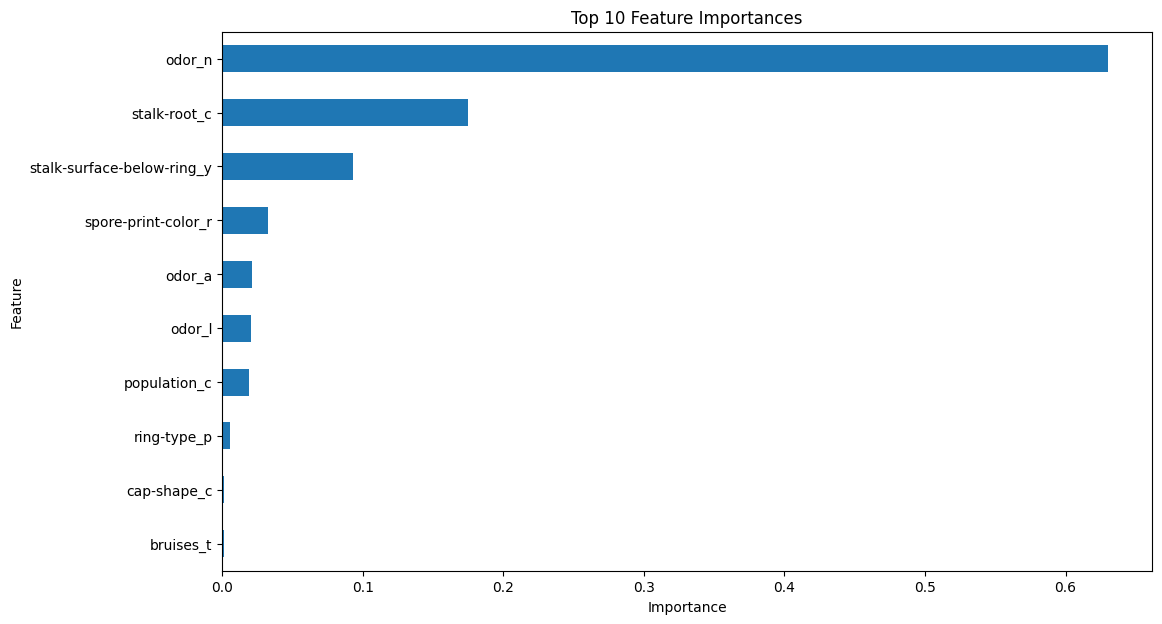

In [11]:
import numpy as np

# Get feature importances
importances = dt_classifier.feature_importances_

# Create a Series for better visualization
feature_importances = pd.Series(importances, index=X_encoded.columns)

# Sort feature importances in descending order and display top 10
top_10_features = feature_importances.nlargest(10)

print("Top 10 Most Important Features:")
display(top_10_features)

# Plot feature importances
plt.figure(figsize=(12, 7))
top_10_features.sort_values(ascending=True).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [12]:
print(report)

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1257
           p       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [13]:
import pickle

# Define the filename for the exported model
model_filename = 'decision_tree_model.pkl'

# Export the trained decision tree classifier
with open(model_filename, 'wb') as file:
    pickle.dump(dt_classifier, file)

print(f"Decision tree model exported to '{model_filename}' successfully.")

Decision tree model exported to 'decision_tree_model.pkl' successfully.
